In [1]:
from pandas import concat, read_csv

codes = 'DE', 'DR', 'V'
df = concat((read_csv(f'R/{code}.csv', index_col=0, dtype=str, na_filter=False) for code in codes), keys=codes, names=('RE',))
df

T  R   E  A DE    DA     H     M
RE I                                    
DE 1    0  0   0  0  8  2947  1425  4611
   1    0  1   1  0  3  1818     0   650
   1    0  1   2  0  7  4735   487   308
   1    0  2   1  0  3  2078  2748     0
   1    0  2   1  1  3   269  5848   189
...    .. ..  .. .. ..   ...   ...   ...
V  467  1  0   7  2  4  6453     0  9665
   467  1  1  10  0  5  6272    62  1417
   467  1  1   6  1  7  5267    78    76
   467  1  2   5  1  6  4602  8211   716
   467  1  2   2  5  7  1979  7396   329

[9110 rows x 8 columns]

In [2]:
from numpy import nan
from string import digits

digit_dict = {'': 0}
for i, d in enumerate(digits, 1):
    digit_dict[d] = i
digit_dict

{'': 0,
 '0': 1,
 '1': 2,
 '2': 3,
 '3': 4,
 '4': 5,
 '5': 6,
 '6': 7,
 '7': 8,
 '8': 9,
 '9': 10}

In [3]:
from pandas import DataFrame
from numpy import uint8

result = {}
for col_name, max_len in df.map(len).max().items():
    for i in range(-max_len, 0):
        result[f'{col_name}{-i}'] = df[col_name].str[i].fillna('').map(digit_dict).astype(uint8)
result_df = DataFrame(result)
result_df

T1  R1  E2  E1  A2  A1  DE2  DE1  DA5  DA4  ...  H5  H4  H3  H2  H1  \
RE I                                                ...                       
DE 1     1   1   0   1   0   1    0    9    0    3  ...   0   2   5   3   6   
   1     1   2   0   2   0   1    0    4    0    2  ...   0   0   0   0   1   
   1     1   2   0   3   0   1    0    8    0    5  ...   0   0   5   9   8   
   1     1   3   0   2   0   1    0    4    0    3  ...   0   3   8   5   9   
   1     1   3   0   2   0   2    0    4    0    0  ...   0   6   9   5   9   
...     ..  ..  ..  ..  ..  ..  ...  ...  ...  ...  ...  ..  ..  ..  ..  ..   
V  467   2   1   0   8   0   3    0    5    0    7  ...   0   0   0   0   1   
   467   2   2   2   1   0   1    0    6    0    7  ...   0   0   0   7   3   
   467   2   2   0   7   0   2    0    8    0    6  ...   0   0   0   8   9   
   467   2   3   0   6   0   2    0    7    0    5  ...   0   9   3   2   2   
   467   2   3   0   3   0   6    0    8    0    2  ...   0   8   4  10   7   

        M5  M4  M3  M2  M1  
RE I                        
DE 1     0   5   7   2   2  
   1     0   0   7   6   1  
   1     0   0   4   1   9  
   1     0   0   0   0   1  
   1     0   0   2   9  10  
...     ..  ..  ..  ..  ..  
V  467   0  10   7   7   6  
   467   0   2   5   2   8  
   467   0   0   0   8   7  
   467   0   0   8   2   7  
   467   0   0   4   3  10  

[9110 rows x 23 columns]

In [4]:
tuple_data = tuple(result_df.to_numpy().T.reshape(23, -1, 10))
len(tuple_data), tuple_data[0].shape

(23, (911, 10))

2026-01-23 09:30:20.626676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769160620.861603      45 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769160620.924387      45 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769160621.445105      45 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769160621.445137      45 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769160621.445139      45 computation_placer.cc:177] computation placer alr

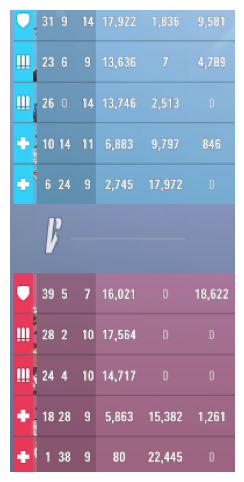

[[ 1  1  4  2  0 10  2  5  2  8 10  3  3  0  2  9  4  7  0 10  6  9  2]
 [ 1  2  3  4  0  7  0 10  2  4  7  4  7  0  0  0  0  8  0  5  8  9 10]
 [ 1  2  3  7  0  1  2  5  2  4  8  5  7  0  3  6  2  4  0  0  0  0  1]
 [ 1  3  2  1  2  5  2  2  0  7  9  9  4  0 10  8 10  8  0  0  9  5  7]
 [ 1  3  0  7  3  5  0 10  0  3  8  5  6  2  8 10  8  3  0  0  0  0  1]
 [ 2  1  4 10  0  6  0  8  2  7  1  3  2  0  0  0  0  1  2  9  7  3  3]
 [ 2  2  3  9  0  3  2  1  2  8  6  7  5  0  0  0  0  1  0  0  0  0  1]
 [ 2  2  3  5  0  5  2  1  2  5  8  2  8  0  0  0  0  1  0  0  0  0  1]
 [ 2  3  2  9  3  9  0 10  0  6  9  7  4  2  6  4  9  3  0  2  3  7  2]
 [ 2  3  0  2  4  9  0 10  0  0  0  9  1  3  3  5  5  6  0  0  0  0  1]]


2026-01-23 09:30:29.574947: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
from pathlib import Path
from tensorflow.random import shuffle
import tensorflow as tf
from tensorflow import gather
from tensorflow.data import Dataset, AUTOTUNE
from tensorflow.image import decode_png, resize
from tensorflow.io import read_file
from matplotlib.pyplot import figure, axis, imshow, show
from numpy import array

image_paths = sorted(map(str, Path().rglob("*.png")))

data_count = len(image_paths)
indices = shuffle(tf.range(data_count))
X_shuffled = gather(image_paths, indices)
y_shuffled = tuple(gather(y, indices) for y in tuple_data)

train_size = int(data_count * .9)
train_X = X_shuffled[:train_size]
val_X = X_shuffled[train_size:]

train_y = tuple(y[:train_size] for y in y_shuffled)
val_y = tuple(y[train_size:] for y in y_shuffled)


def preprocess_image(path, label):
    image = decode_png(read_file(path), channels=3)[230:930, 530:1370]
    hud_parts = [
        image[:, :40], image[:, 390:420], image[:, 450:480],
        image[:, 500:530], image[:, 570:640], image[:, 670:740], image[:, 770:]
    ]
    cropped = tf.concat(hud_parts, axis=1)
    resized = resize(cropped, (400, 194)) / 255
    return resized, label


def make_dataset(X, y, shuffle=False, batch_size=32):
    ds = Dataset.from_tensor_slices((X, y))
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_X, train_y, shuffle=True)
val_ds = make_dataset(val_X, val_y, shuffle=False)
for x_batch, y_batch in train_ds.take(1):
    figure(figsize=(6, 6))
    axis("off")
    imshow(x_batch[0])
    show()
    print(array(y_batch).reshape(23, -1).T.reshape(-1, 10, 23)[0])

In [6]:
from tensorflow.keras import layers, models

In [7]:
class LearnablePositionalEncoding2D(tf.keras.layers.Layer):
    def __init__(self, height, width, channels):
        super().__init__()
        self.pe = self.add_weight((1, height, width, channels), "random_normal")

    def call(self, x):
        return x + self.pe

In [8]:
def transformer_block(x, num_heads=8, key_dim=64, ff_dim=512, dropout=0.1):
    attn = layers.MultiHeadAttention(num_heads, key_dim)(x, x)
    attn = layers.Dropout(dropout)(attn)
    x = layers.LayerNormalization()(x + attn)

    ffn = layers.Dense(ff_dim, "relu")(x)
    ffn = layers.Dense(x.shape[-1])(ffn)
    ffn = layers.Dropout(dropout)(ffn)

    return layers.LayerNormalization()(x + ffn)

In [9]:
unique_count = result_df.nunique()


def build_model(image_size=x_batch.shape[1:]):  # (400, 194, 3)
    inputs = layers.Input(shape=image_size)

    # CNN Backbone (Transfer Learning)
    backbone = tf.keras.applications.ResNet50V2(False, input_tensor=inputs)

    x = backbone.output  # (H', W', C)
    x = layers.Conv2D(256, 1, activation="relu")(x)

    # Resize to grid size
    x = layers.Resizing(10, 23)(x)

    # Positional Encoding
    x = LearnablePositionalEncoding2D(10, 23, 256)(x)

    # Flatten for Transformer
    x = layers.Reshape((10 * 23, 256))(x)

    # Transformer Encoder
    for _ in range(4):
        x = transformer_block(x)

    # Restore grid
    x = layers.Reshape((10, 23, 256))(x)

    outputs = []
    for idx, key in enumerate(result):
        outputs.append(layers.Dense(unique_count[key], name=f"{idx:02d}_{key}")(x[:, :, idx, :]))
    
    model = models.Model(inputs, outputs)
    return model

Sparse를 One Hot 처리!

In [89]:
import tensorflow as tf


class CustomSparseCategoricalFocalCrossentropy(tf.keras.losses.Loss):
    def __init__(self, alpha=0.25, gamma=2.0, from_logits=False, **kwargs):
        super().__init__(**kwargs)
        self.alpha = tf.constant(alpha) if isinstance(alpha, (int, float)) else tf.constant(alpha, dtype=tf.float32)
        self.gamma = gamma
        self.from_logits = from_logits

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)

        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred)

        # 정답 클래스 확률 p_t 추출
        p_t = tf.gather_nd(y_pred, tf.stack([tf.range(tf.shape(y_true)[0]), y_true], axis=1))

        # alpha 적용: 스칼라 또는 per-class
        if len(self.alpha.shape) == 0:  # 스칼라
            alpha_t = self.alpha
        else:  # list[float] -> 클래스별
            alpha_t = tf.gather(self.alpha, y_true)

        # Focal loss 계산
        focal_weight = tf.pow(1 - p_t, self.gamma)
        loss = alpha_t * focal_weight * (-tf.math.log(tf.clip_by_value(p_t, 1e-7, 1 - 1e-7)))

        return loss

In [90]:
from numpy import unique, insert

losses = []
for y in tuple_data:
    counts = unique(y, return_counts=True)[1][1:]
    r = 1 / counts
    alpha = insert(r / sum(r) * len(counts), 0, 0)
    losses.append(CustomSparseCategoricalFocalCrossentropy(alpha, from_logits=True))
    print(alpha)
len(losses)

[0.         0.99502378 1.00497622]
[0.         1.50020733 0.74968901 0.75010366]
[0.         0.01341114 0.02432201 0.0968016  0.46539233 4.40007292]
[0.         0.90752362 0.93676814 0.96900103 0.99797448 0.97318678
 0.99247902 1.00464989 1.01597627 1.11669263 1.08574814]
[0.00000000e+00 1.51482221e-03 4.58508490e-03 1.85155658e-02
 1.61496879e-01 2.90694382e+00 2.90694382e+00]
[0.         0.36664823 0.57538644 0.67346964 0.73366057 0.93047379
 1.00653432 1.15436905 1.37322712 1.46007152 1.72615932]
[0.         0.02402746 1.97597254]
[0.         1.14230743 1.08658511 1.11235929 1.00677943 0.95600836
 0.81295602 0.86003841 0.8769683  0.96742649 1.17857116]
[0.         0.05640314 1.94359686]
[0.         1.59512328 0.83892895 0.74263315 0.70385335 0.78289207
 0.87809718 0.92215223 1.06692283 1.23469848 1.23469848]
[0.         0.99010431 0.98357615 0.98249648 0.99671971 1.0011793
 1.01710715 0.96867348 1.01136079 1.0419724  1.00681023]
[0.         0.98900154 1.00111626 0.98574825 0.9771765

23

In [91]:
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy

clear_session()
model = build_model()
model.compile(AdamW(), losses, metrics=[SparseCategoricalAccuracy] * 23)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 400, 194,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 406, 200,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 200, 97,   │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 202, 99,   │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 100, 49,   │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 100, 49,   │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 100, 49,   │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 100, 49,   │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 100, 49,   │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 100, 49,   │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 102, 51,   │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 100, 49,   │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 100, 49,   │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 100, 49,   │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 100, 49,   │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 100, 49,   │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 100, 49,   │          0 │ conv2_block1_0_c

 Total params: 27,359,174 (104.37 MB)

 Trainable params: 27,313,734 (104.19 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [92]:
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
    train_ds,
    epochs=256,
    callbacks=EarlyStopping(patience=16, verbose=1, restore_best_weights=True),
    validation_data=val_ds
)

Epoch 1/256


ValueError: Can not squeeze dim[1], expected a dimension of 1, got 10 for '{{node compile_loss/custom_sparse_categorical_focal_crossentropy/Squeeze}} = Squeeze[T=DT_INT32, squeeze_dims=[1]](compile_loss/custom_sparse_categorical_focal_crossentropy/Cast_1)' with input shapes: [?,10].

In [75]:
items = []
for item in history.history.items():
    if key.startswith("val_") and key.endswith("_sparse_categorical_accuracy"):
        items.append((key, value))
items.sort(key=lambda item: item[1])
for key, value in items:
    print(f"{key}: {value}")

val_dense_10_sparse_categorical_accuracy: 0.9152173399925232
val_dense_11_sparse_categorical_accuracy: 0.9956521391868591
val_dense_12_sparse_categorical_accuracy: 0.6423913836479187
val_dense_13_sparse_categorical_accuracy: 0.9956521391868591
val_dense_14_sparse_categorical_accuracy: 0.9163042902946472
val_dense_15_sparse_categorical_accuracy: 0.997826099395752
val_dense_16_sparse_categorical_accuracy: 0.9706522226333618
val_dense_17_sparse_categorical_accuracy: 0.988043487071991
val_dense_18_sparse_categorical_accuracy: 0.979347825050354
val_dense_19_sparse_categorical_accuracy: 0.9826087355613708
val_dense_20_sparse_categorical_accuracy: 0.989130437374115
val_dense_21_sparse_categorical_accuracy: 0.9423912763595581
val_dense_22_sparse_categorical_accuracy: 0.97826087474823
val_dense_23_sparse_categorical_accuracy: 0.968478262424469
val_dense_24_sparse_categorical_accuracy: 0.9152173399925232
val_dense_25_sparse_categorical_accuracy: 0.9869565367698669
val_dense_26_sparse_categorical

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


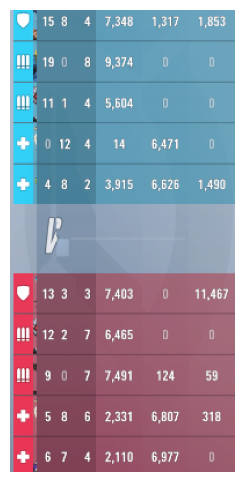

In [95]:
from numpy import array

for x_batch, y_batch in val_ds.take(1):
    x_sample = x_batch[0:1]
    y_sample = tuple(y[0] for y in y_batch)
    y_pred = tuple(y[0] for y in model.predict(x_sample))
    figure(figsize=(6, 6))
    axis("off")
    imshow(x_batch[0])
    show()

In [122]:
y_true_0 = array(y_sample).T
y_pred_0 = array([y.argmax(1) for y in y_pred]).T
for y1, y2 in zip(y_true_0, y_pred_0):
    for y3, y4, y5 in zip(y1, y2, y1 == y2):
        if y5:
            print(f"{y3} == {y4}", end="  ")
        else:
            print(f"{y3} != {y4}", end="  ")
    print()

0 == 0  0 == 0  1 == 1  5 == 5  0 == 0  8 == 8  0 == 0  4 == 4  0 == 0  7 == 7  3 == 3  4 == 4  8 == 8  0 == 0  1 == 1  3 == 3  1 == 1  7 == 7  0 == 0  1 == 1  8 == 8  5 == 5  3 == 3  
0 == 0  1 == 1  1 == 1  9 == 9  0 == 0  0 == 0  0 == 0  8 == 8  0 == 0  9 == 9  3 == 3  7 == 7  4 == 4  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  
0 == 0  1 == 1  1 == 1  1 == 1  0 == 0  1 == 1  0 != 1  4 == 4  0 == 0  5 == 5  6 == 6  0 == 0  4 == 4  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  
0 == 0  2 == 2  0 == 0  0 == 0  1 != 2  2 == 2  0 == 0  4 == 4  0 == 0  0 == 0  0 == 0  1 == 1  4 != 0  0 == 0  6 == 6  4 == 4  7 == 7  1 == 1  0 == 0  0 == 0  0 == 0  0 == 0  0 == 0  
0 == 0  2 == 2  0 == 0  4 == 4  0 != 1  8 == 8  0 == 0  2 == 2  0 == 0  3 == 3  9 == 9  1 == 1  5 == 5  0 == 0  6 == 6  6 == 6  2 == 2  6 == 6  0 == 0  1 == 1  4 == 4  9 == 9  0 == 0  
1 == 1  0 == 0  1 == 1  3 == 3  0 == 0  3 == 3  0 == 0  3 == 3  0 == 0  7 =